# 03 -- Hybrid retrieval: объединение и ablations

RRF складывает обратные ранги, не смешивая несопоставимые TF-IDF, BM25 и частоты напрямую.
Подбираю небольшую сетку весов только на development. Нулевая выдача по запросу остается нулем в метрике.
Потолок union считаю по **всем** dev-запросам, включая те, для которых ни один метод не нашел позитив.

In [1]:
from pathlib import Path
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

hy_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
get_ipython().run_line_magic('run', str(hy_root / 'notebooks/common.ipynb'))
hy_out = hy_root / 'outputs'
hy_seed = 143


In [2]:
hy_items = pd.read_parquet(hy_out / 'cache/items.parquet', columns=['item_id'])
hy_queries = pd.read_parquet(hy_out / 'cache/eval_queries.parquet')
hy_dev = hy_queries[hy_queries.split.eq('dev')]
hy_all_truth = json.loads((hy_out / 'cache/truth.json').read_text())
hy_truth = {q: hy_all_truth[q] for q in hy_dev.query_id}
hy_candidates = pd.concat(
    [
        pd.read_parquet(hy_out / f'cache/candidates_{s}.parquet')
        for s in ['word', 'char', 'bm25', 'bm25_title', 'history']
    ],
    ignore_index=True,
)
hy_candidates = hy_candidates[hy_candidates.query_id.isin(hy_dev.query_id)]
hy_sources = [
    'word',
    'word_local',
    'char',
    'char_local',
    'bm25',
    'bm25_local',
    'bm25_title',
    'bm25_title_local',
    'history',
    'history_local',
    'history_context',
    'similar_history',
    'similar_history_local',
    'naive_bayes_local',
    'popularity_local',
]


In [3]:
hy_candidates = hy_candidates[hy_candidates.source.isin(hy_sources)]
hy_union = predictions_from_frame(hy_candidates, hy_items, k=100000)
hy_ceiling = recall_table(hy_union, hy_truth, ks=(100000,)).rename(
    columns={'recall@100000': 'union_recall'}
)
display(
    hy_ceiling.merge(hy_dev[['query_id', 'regime']], on='query_id')
    .groupby('regime')
    .union_recall.mean()
)
hy_ceiling.to_csv(hy_out / 'validation/union_ceiling_dev.csv', index=False)


regime
cold    0.868306
warm    0.877714
Name: union_recall, dtype: float64

In [4]:
hy_trials = []
hy_configs = []
for hy_local_weight in [1.0, 2.0, 4.0]:
    for hy_history_weight in [0.5, 1.5, 3.0]:
        hy_weights = {s: 1.0 for s in hy_sources}
        hy_weights.update(
            {s: hy_local_weight for s in hy_sources if s.endswith('_local')}
        )
        hy_weights.update(
            {
                s: hy_history_weight
                * (hy_local_weight if s.endswith('_local') else 1.0)
                for s in hy_sources
                if 'history' in s
            }
        )
        hy_weights['naive_bayes_local'] = 0.25
        hy_weights['popularity_local'] = 0.15
        hy_config_id = len(hy_configs)
        hy_configs.append(hy_weights)
        hy_ranked = rrf(hy_candidates, hy_weights, constant=30, top_k=100)
        hy_pred = predictions_from_frame(hy_ranked, hy_items, k=100)
        hy_result = recall_table(hy_pred, hy_truth).merge(
            hy_dev[['query_id', 'regime']], on='query_id'
        )
        hy_scores = hy_result.groupby('regime')['recall@50'].mean()
        # Доля знакомых текстов берется из unlabeled benchmark, а не из test labels.
        hy_warm_share = json.loads((hy_out / 'validation/overlap.json').read_text())[
            'benchmark_text_seen_share'
        ]
        hy_objective = (
            hy_warm_share * hy_scores['warm'] + (1 - hy_warm_share) * hy_scores['cold']
        )
        hy_trials.append(
            {
                'config': hy_config_id,
                'local_weight': hy_local_weight,
                'history_weight': hy_history_weight,
                'warm': hy_scores['warm'],
                'cold': hy_scores['cold'],
                'weighted_dev': hy_objective,
            }
        )


In [5]:
hy_trials = pd.DataFrame(hy_trials)
hy_best = int(
    hy_trials.sort_values(['weighted_dev', 'config'], ascending=[False, True]).iloc[0][
        'config'
    ]
)
hy_weights = hy_configs[hy_best]
write_json(
    {
        'weights': hy_weights,
        'constant': 30,
        'selected_on': 'dev',
        'warm_share': hy_warm_share,
    },
    hy_out / 'models/hybrid.json',
)
hy_trials.to_csv(hy_out / 'validation/hybrid_trials.csv', index=False)
display(hy_trials.sort_values('weighted_dev', ascending=False))


,config,local_weight,history_weight,warm,cold,weighted_dev
7,7,4.0,1.5,0.731905,0.696806,0.709961
6,6,4.0,0.5,0.730262,0.695472,0.708511
8,8,4.0,3.0,0.727405,0.691306,0.704835
3,3,2.0,0.5,0.723345,0.692472,0.704043
4,4,2.0,1.5,0.722321,0.692139,0.703451
5,5,2.0,3.0,0.702845,0.676681,0.686487
0,0,1.0,0.5,0.686393,0.654014,0.666149
1,1,1.0,1.5,0.678250,0.646014,0.658096
2,2,1.0,3.0,0.609131,0.609731,0.609506


## Удаление источников по одному
Ablation ниже не перенастраивает оставшиеся веса: это вклад канала в выбранную конфигурацию,
а не доказательство, что он бесполезен при любой настройке. Слишком много слабых каналов способны ухудшить RRF.

,drop,regime,recall@50
0,none,cold,0.696806
1,none,warm,0.731905
2,local,cold,0.222125
3,local,warm,0.173310
4,history,cold,0.691472
5,history,warm,0.729095
6,char,cold,0.678981
7,char,warm,0.712488
8,word,cold,0.677847
9,word,warm,0.714679


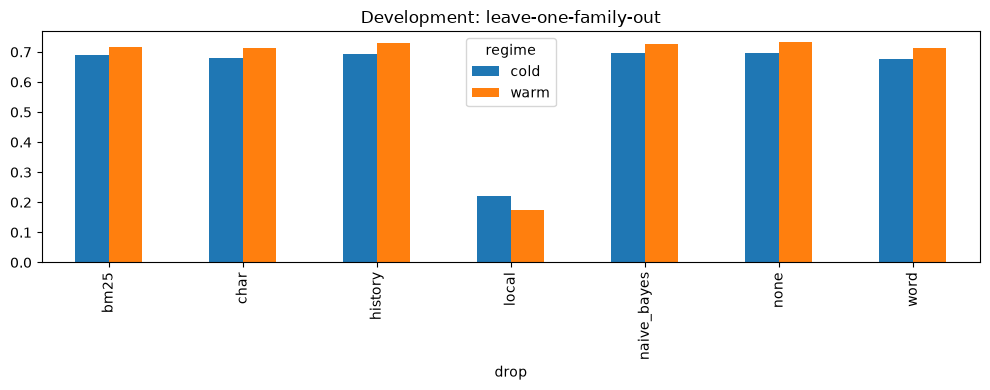

In [6]:
hy_ablations = []
for hy_drop in ['none', 'local', 'history', 'char', 'word', 'bm25', 'naive_bayes']:
    hy_ab_weights = {
        s: w for s, w in hy_weights.items() if hy_drop == 'none' or hy_drop not in s
    }
    hy_pred = predictions_from_frame(
        rrf(hy_candidates, hy_ab_weights, constant=30, top_k=100), hy_items, k=100
    )
    hy_result = recall_table(hy_pred, hy_truth).merge(
        hy_dev[['query_id', 'regime']], on='query_id'
    )
    for hy_regime, hy_part in hy_result.groupby('regime'):
        hy_ablations.append(
            {
                'drop': hy_drop,
                'regime': hy_regime,
                'recall@50': hy_part['recall@50'].mean(),
            }
        )
hy_ablations = pd.DataFrame(hy_ablations)
hy_ablations.to_csv(hy_out / 'validation/hybrid_ablations.csv', index=False)
display(hy_ablations)
hy_ablations.pivot(index='drop', columns='regime', values='recall@50').plot.bar(
    figsize=(10, 4), title='Development: leave-one-family-out'
)
plt.tight_layout()
plt.savefig(hy_out / 'figures/hybrid_ablations.png', dpi=150)
plt.show()
